# 2장 1강: AARRR 프레임워크 개요와 단계별 분석 목적 — 실습문제

## 실습 목표

- Ravenstack의 사용자 여정을 AARRR 5단계로 구분할 수 있다.
- 각 단계의 분석 목적과 활용 가능한 데이터를 연결할 수 있다.
- 이벤트 로그의 사용자·행동·시점·속성 컬럼을 구분할 수 있다.
- 분석 질문에 맞게 퍼널·코호트·세그멘테이션 분석을 선택할 수 있다.
- 그룹별 Activation 지표를 비교하여 점검 대상을 찾을 수 있다.

## 실습 환경 / 데이터

- Python
- pandas
- `ravenstack_accounts.csv`
- `ravenstack_subscriptions.csv`
- `ravenstack_feature_usage.csv`

Ravenstack은 기업 고객에게 구독형 소프트웨어를 제공하는 B2B SaaS 서비스입니다.

Ravenstack의 AARRR 단계는 다음과 같이 연결할 수 있습니다.

| 단계 | Ravenstack에서의 의미 | 활용 데이터 예시 |
|---|---|---|
| Acquisition | 고객사가 유입되어 가입함 | 가입일, 유입 경로 |
| Activation | 구독 후 제품 기능을 처음 사용함 | 기능 사용 기록 |
| Retention | 제품 사용과 구독을 계속 유지함 | 반복 사용 기록, 이탈 여부 |
| Referral | 기존 고객이 다른 고객을 추천함 | 추천 전송·추천 가입 이벤트 |
| Revenue | 유료 구독에서 반복 매출이 발생함 | MRR, 요금제 |

> 제공된 데이터에는 고객 추천 행동을 직접 기록한 이벤트가 없습니다. `referral_source`는 고객의 유입 경로이며, 기존 고객이 추천 행동을 했다는 사실을 직접 보여주는 Referral 이벤트와는 구분해야 합니다.

> 풀이 데이터: 이 폴더의 `data/` CSV. RavenStack은 River @ Rivalytics의 합성 교육용 데이터다. 실제 사업 성과로 일반화하지 않는다.

## 실습 준비

1. 필요한 라이브러리를 불러오세요.
2. 세 CSV 파일을 각각 `accounts`, `subscriptions`, `feature_usage`에 불러오세요.
3. 각 데이터의 행과 열 개수, 상위 5개 행을 확인하세요.
4. 분석 대상 컬럼의 자료형과 결측치 개수를 확인하세요.
5. `signup_date`, `start_date`, `end_date`, `usage_date`를 날짜형으로 변환하세요.
6. `feature_usage`에서 이벤트 식별자인 `usage_id`의 중복 개수를 확인하세요.
7. 기능별 이벤트 기록 수와 `usage_count`의 기초 통계량을 확인하세요.

In [1]:
from pathlib import Path
import pandas as pd
DATA_DIR = Path('data')

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib import font_manager
if 'Malgun Gothic' in {f.name for f in font_manager.fontManager.ttflist}:
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams.update({'axes.unicode_minus': False, 'figure.figsize': (8,4), 'font.size': 11})
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 30)
def show_rates(frame):
    display(frame.style.format({c: '{:.2%}' for c in frame.columns if 'rate' in str(c) or 'conversion' in str(c)}, na_rep='—'))
def bars(series, title, ylabel, percent=False):
    ax = (series * (100 if percent else 1)).plot.bar(color='#32689b', rot=0)
    ax.set(title=title, ylabel=ylabel, xlabel='')
    ax.set_ylim(bottom=0)
    plt.tight_layout(); plt.show()
def make_funnel(counts, labels):
    f = pd.DataFrame({'count': counts}, index=labels)
    prev = f['count'].shift().replace(0, np.nan)
    f['conversion_rate'] = f['count'] / prev
    f['drop_rate'] = 1 - f.conversion_rate
    f['drop_count'] = f['count'].shift() - f['count']
    return f

accounts = pd.read_csv(DATA_DIR / 'ravenstack_accounts.csv')
subscriptions = pd.read_csv(DATA_DIR / 'ravenstack_subscriptions.csv')
feature_usage = pd.read_csv(DATA_DIR / 'ravenstack_feature_usage.csv')
tables = {'accounts':accounts,'subscriptions':subscriptions,'feature_usage':feature_usage}
for name, df in tables.items():
    for col in df.columns:
        if col.endswith('_date') or col in ['submitted_at', 'closed_at']:
            df[col] = pd.to_datetime(df[col], errors='raise')
    print(name, df.shape)
    display(df.head())
    display(pd.DataFrame({'dtype':df.dtypes.astype(str), 'missing':df.isna().sum()}))
if 'subscriptions' in tables:
    assert subscriptions.subscription_id.is_unique
    display(subscriptions.mrr_amount.describe())
    display(subscriptions.plan_tier.value_counts())
if 'feature_usage' in tables:
    print('usage_id 중복:', feature_usage.usage_id.duplicated().sum())
    print('구독 수 / 이벤트 행 수:', subscriptions.subscription_id.nunique(), len(feature_usage))
    display(feature_usage.feature_name.value_counts())
    display(feature_usage.usage_count.describe())
    assert feature_usage.subscription_id.isin(subscriptions.subscription_id).all()

accounts (500, 10)


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


,dtype,missing
account_id,object,0
account_name,object,0
industry,object,0
country,object,0
signup_date,datetime64[ns],0
referral_source,object,0
plan_tier,object,0
seats,int64,0
is_trial,bool,0
churn_flag,bool,0


subscriptions (5000, 14)


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaT,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaT,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaT,Enterprise,27,5373,64476,False,False,False,False,monthly,True


...

count     5000.000000
mean      2267.749400
std       3421.375348
min          0.000000
25%        285.000000
50%        931.000000
75%       2786.000000
max      33830.000000
Name: mrr_amount, dtype: float64

plan_tier
Enterprise    1723
Pro           1675
Basic         1602
Name: count, dtype: int64

usage_id 중복: 21
구독 수 / 이벤트 행 수: 5000 25000


feature_name
feature_32    659
feature_12    659
feature_6     655
feature_17    651
feature_34    650
             ... 
feature_19    589
feature_18    588
feature_35    587
feature_5     577
feature_23    563
Name: count, Length: 40, dtype: int64

count    25000.000000
mean        10.021000
std          3.143729
min          0.000000
25%          8.000000
50%         10.000000
75%         12.000000
max         26.000000
Name: usage_count, dtype: float64

---

## 필수 1. Ravenstack의 AARRR 지표 지도 만들기

### 문제 1-1. 데이터에서 확인 가능한 단계별 대표 지표 계산하기

#### 문제 설명

Ravenstack의 세 테이블을 이용하여 AARRR 단계별 대표 지표를 계산하고, 제공된 데이터만으로 직접 측정하기 어려운 단계도 확인하세요.

이번 문제에서는 다음 기준을 사용합니다.

- Acquisition: 가입한 고유 고객사 수
- Activation: 전체 구독 중 기능 사용 기록이 한 번 이상 있는 구독의 비율
- Retention: 전체 구독 중 현재 `churn_flag`가 `False`인 구독의 비율
- Referral: 제공된 데이터로 직접 계산할 수 없음
- Revenue: 종료일이 없고 체험 구독이 아닌 현재 활성 유료 구독의 MRR 합계

> 여기에서 Retention은 학습을 위한 간단한 대리 지표입니다. 특정 기간 후 다시 사용한 비율을 계산한 정식 리텐션과는 다릅니다.

#### 요구사항

1. 가입한 고유 고객사 수를 `acquired_accounts`로 계산하세요.
2. 기능 사용 기록이 있는 고유 구독 수를 전체 구독 수로 나누어 `activation_rate`를 계산하세요.
3. `churn_flag`가 `False`인 구독의 비율을 `non_churned_rate`로 계산하세요.
4. 종료일이 없고 체험 구독이 아닌 구독의 MRR 합계를 `current_paid_mrr`로 계산하세요.
5. 네 지표를 알아보기 쉬운 형식으로 출력하세요.
6. 각 지표를 AARRR 단계와 연결하고 분석 목적을 설명하세요.
7. Referral 단계를 직접 측정하려면 어떤 이벤트가 추가로 필요한지 제안하세요.

#### 해석 질문

**Q1.** 기능 사용 기록이 있는 구독 비율은 어느 AARRR 단계와 연결되나요?  
**Q2.** `non_churned_rate`를 정식 리텐션율과 동일하게 보면 안 되는 이유는 무엇인가요?  
**Q3.** `referral_source`만으로 Referral 행동을 직접 측정할 수 있나요?  
**Q4.** MRR은 어느 AARRR 단계와 연결되나요?

#### 제출 결과

- AARRR 단계별 대표 지표 계산 코드와 결과
- 각 지표의 단계 및 분석 목적
- Referral 측정에 필요한 이벤트 제안
- Q1~Q4 답변

In [2]:
acquired_accounts = accounts.account_id.nunique()
activation_rate = subscriptions.subscription_id.isin(feature_usage.subscription_id).mean()
non_churned_rate = (~subscriptions.churn_flag).mean()
current_paid_mrr = subscriptions.loc[subscriptions.end_date.isna() & ~subscriptions.is_trial, 'mrr_amount'].sum()
print(f'Acquisition: {acquired_accounts:,}개 / Activation: {activation_rate:.2%} / Retention 대리 지표: {non_churned_rate:.2%} / Revenue MRR: {current_paid_mrr:,.2f}')
print('Referral: 직접 측정 불가')

Acquisition: 500개 / Activation: 99.34% / Retention 대리 지표: 90.28% / Revenue MRR: 10,159,608.00
Referral: 직접 측정 불가


### 필수 1 답변
- **Q1.** Activation 99.34%: 기능을 한 번이라도 경험한 구독의 비중이다. Acquisition은 가입 확보, Revenue는 유료 반복 매출을 확인한다.
- **Q2.** 미이탈 비중 90.28%에는 기준 코호트·경과 기간·재사용 행동이 없어 정식 리텐션과 다르다.
- **Q3.** 아니다. 추천 발송·링크 클릭·추천을 통한 가입 이벤트와 추천자/피추천자 ID, 시각이 추가로 필요하다.
- **Q4.** MRR은 Revenue 단계이며 현재 유료 매출 규모를 보여준다.

---

## 필수 2. 요금제별 Activation 지표 비교하기

### 문제 2-1. 2024년 12월 제품 활성률을 요금제별로 비교하기

#### 문제 설명

프로덕트팀은 다음 질문에 답하려고 합니다.

> 2024년 12월에 어떤 요금제의 제품 활성률이 상대적으로 낮은가?

이 질문은 사용자를 요금제별로 나누어 비교하므로 **세그멘테이션 분석**에 해당하며, AARRR 중 Activation 단계를 살펴봅니다.

이번 실습에서 제품 활성률은 다음과 같이 정의합니다.

> 12월 제품 활성 유료 구독 수 ÷ 12월 이용 가능 유료 구독 수

#### 요구사항

1. 2024년 12월의 시작일과 마지막 날을 설정하세요.
2. 12월에 이용 가능한 유료 구독을 `eligible_dec`에 저장하세요.
3. 12월에 기능을 사용한 구독 ID를 `active_subscription_ids`로 준비하세요.
4. `eligible_dec`에 `is_product_active` 컬럼을 만드세요.
5. `plan_tier`별로 다음 값을 집계하여 `plan_activation`을 만드세요.
   - 이용 가능 유료 구독 수
   - 제품 활성 유료 구독 수
   - 제품 활성률
6. 제품 활성률이 낮은 순서로 정렬하고 백분율로 출력하세요.
7. 가장 낮은 요금제를 찾아 개선을 위해 추가로 확인할 내용을 제안하세요.
8. 이 질문에 세그멘테이션 분석이 적절한 이유를 설명하세요.

#### 해석 질문

**Q1.** 이 분석은 AARRR 중 어느 단계에 해당하나요?  
**Q2.** 어떤 분석 기법을 사용했으며, 그 이유는 무엇인가요?  
**Q3.** 제품 활성률이 가장 낮은 요금제는 무엇인가요?  
**Q4.** 해당 요금제에서 추가로 어떤 데이터를 확인하면 좋을까요?

#### 제출 결과

- `plan_activation` 집계 코드와 결과
- AARRR 단계와 분석 기법
- 우선 점검할 요금제
- 추가 확인 데이터
- Q1~Q4 답변

,eligible,active,activation_rate
plan_tier,,,
Pro,1342,260,19.37%
Basic,1267,247,19.49%
Enterprise,1372,281,20.48%


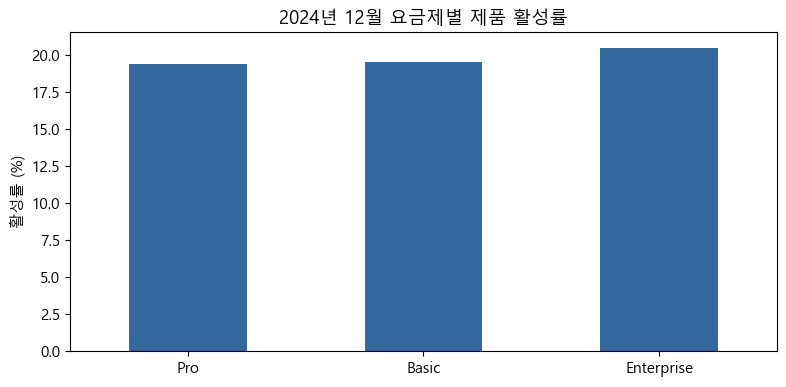

In [3]:
dec_start, dec_end = pd.Timestamp('2024-12-01'), pd.Timestamp('2024-12-31')
# 종료일 당일까지 사용 가능하다고 가정: 12월과 구독 기간이 하루 이상 겹침.
eligible_dec = subscriptions.loc[(subscriptions.start_date <= dec_end) & (subscriptions.end_date.isna() | (subscriptions.end_date >= dec_start)) & ~subscriptions.is_trial].copy()
active_subscription_ids = feature_usage.loc[feature_usage.usage_date.between(dec_start, dec_end), 'subscription_id'].unique()
eligible_dec['is_product_active'] = eligible_dec.subscription_id.isin(active_subscription_ids)
def activation_by(column):
    return eligible_dec.groupby(column).agg(eligible=('subscription_id','nunique'), active=('is_product_active','sum'), activation_rate=('is_product_active','mean')).sort_values('activation_rate')
plan_activation = activation_by('plan_tier')
show_rates(plan_activation)
bars(plan_activation.activation_rate, '2024년 12월 요금제별 제품 활성률', '활성률 (%)', True)

### 필수 2 답변
- **Q1.** 문제에서 정의한 Activation 단계다.
- **Q2.** 요금제라는 속성으로 집단을 나누는 세그멘테이션이다.
- **Q3.** Pro (19.37%)이다.
- **Q4.** 가입 기간, 온보딩 완료, 기능 오류, 실제 사용 가능한 일수를 확인한다. 월내 사용 기록 존재를 세는 실습 정의이며 최초 활성화만 측정하는 지표는 아니다.

---

## 과제 1. 평가 문항 기반 독립 과제

### 문제 3-1. 결제 주기별 Activation 지표 비교하기

#### 문제 설명

프로덕트팀은 2024년 12월 제품 활성률이 월간 결제 구독과 연간 결제 구독에서 다르게 나타나는지 확인하려고 합니다.

> 이 과제는 필수 2의 요금제별 세그멘테이션을 `billing_frequency`에 동일하게 적용하는 문제입니다.

#### 요구사항

1. 필수 2에서 만든 `eligible_dec`과 `is_product_active`를 사용하세요.
2. `billing_frequency`별로 다음 값을 집계하여 `billing_activation`을 만드세요.
   - 이용 가능 유료 구독 수
   - 제품 활성 유료 구독 수
   - 제품 활성률
3. 제품 활성률이 낮은 순서로 정렬하고 백분율로 출력하세요.
4. 제품 활성률이 더 낮은 결제 주기를 찾으세요.
5. 해당 그룹을 우선 점검 대상으로 정하고 추가로 확인할 내용을 한 가지 제안하세요.
6. 이 분석의 AARRR 단계와 분석 기법을 설명하세요.

#### 해석 질문

**Q1.** 제품 활성률이 더 낮은 결제 주기는 무엇인가요?  
**Q2.** 이 분석은 어떤 AARRR 단계와 분석 기법에 해당하나요?  
**Q3.** 두 그룹의 제품 활성률 차이만으로 결제 주기가 낮은 활성의 원인이라고 결론 내릴 수 있나요?

**Q4.** 퍼널 분석·코호트 리텐션 분석·세그멘테이션을 표로 정리하세요. 각 분석의 계산 또는 분류 원리, 해결하려는 분석 질문, 관련 AARRR 단계를 설명하세요. 전환율·이탈률의 분모, 코호트의 시작 기준과 경과 기간, 세그먼트 분류 기준을 포함하세요.

#### 제출 결과

- `billing_activation` 집계 코드와 결과
- 우선 점검할 결제 주기
- 추가 확인 내용
- AARRR 단계와 분석 기법
- Q1~Q4 답변

,eligible,active,activation_rate
billing_frequency,,,
annual,1968,385,19.56%
monthly,2013,403,20.02%


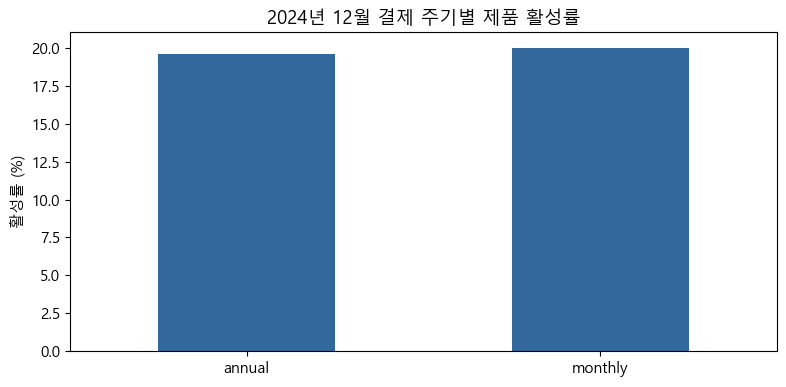

In [4]:
billing_activation = activation_by('billing_frequency')
show_rates(billing_activation)
bars(billing_activation.activation_rate, '2024년 12월 결제 주기별 제품 활성률', '활성률 (%)', True)

### 과제 1 답변
- **Q1.** annual (19.56%)이다. 해당 집단의 온보딩 완료율을 먼저 확인한다.
- **Q2.** Activation 단계의 결제 주기별 세그멘테이션이다.
- **Q3.** 아니다. 요금제·가입 시점·규모가 다를 수 있어 원인을 분리해야 한다.
- **Q4.** 아래와 같이 구분한다.

| 분석 | 원리·분모·기준 | 질문 | AARRR |
|---|---|---|---|
| 퍼널 | 순차 도달 집합, 현재 단계/이전 단계, 이탈률=1−전환율 | 어디에서 미도달하는가? | Acquisition→Activation→Revenue 등 |
| 코호트 리텐션 | 가입 또는 첫 사용 월로 묶고 경과 N개월 사용자를 최초 코호트 크기로 나눔 | 같은 출발 집단이 돌아오는가? | Retention |
| 세그멘테이션 | 요금제·결제 주기 등 속성으로 분류 후 같은 정의의 지표 비교 | 어느 집단이 낮은가? | 분석 지표에 따라 모든 단계 |

---

## 실습 마무리

아래 질문에 답하세요.

1. Ravenstack의 사용자 여정을 어떤 AARRR 단계로 나누었나요?
2. 각 단계는 어떤 분석 질문에 답하기 위해 사용했나요?
3. 제공된 데이터에서 직접 측정하기 어려운 단계는 무엇이었나요?
4. 요금제와 결제 주기별 비교에는 어떤 분석 기법을 사용했나요?
5. 분석 결과를 근거로 어떤 대상을 우선 점검했나요?

### 마무리 답변
1. Acquisition·Activation·Retention·Referral·Revenue로 나눴다.
2. 가입 확보·첫 사용·재사용·추천·수익 발생을 각각 질문한다.
3. 직접 추천 행동은 측정할 수 없다.
4. 요금제와 결제 주기에 따른 세그멘테이션을 사용했다.
5. 위 표에서 제품 활성률이 가장 낮은 집단을 우선 점검했다.